# <span style=color:red;>♦ Jypyter Notebook - Initial Correlation analysis</span>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# 1. Load the College Board extracted data
df_cb = pd.read_csv('data/sat_comprehensive_capstone_data.csv')

# 1a. Select key columns for initial correlation
# We focus on Overall Targets, Participation, and key 'Met Benchmark' percentages
core_features = [
    'Total_Participation_Rate', 
    'Mean_Total', 'Mean_ERW', 'Mean_Math',
    'Gen_Female_Met_Both', 'Gen_Male_Met_Both',
    'Inc_Lowest_Met_Both', 'Inc_Highest_Met_Both',
    'Loc_City_Met_Both', 'Loc_TownRural_Met_Both',
    'Edu_NoHS_Met_Both', 'Edu_Grad_Met_Both'
]

# 1b. Print all columns to see the exact names (useful for debugging)
print(df_cb.columns.tolist())

# 2. Using a 'fuzzy' search to find your core target and predictor columns
# This helps avoid KeyErrors caused by slight naming differences
target_cols = [col for col in df_cb.columns if 'Mean' in col and 'Total' in col]
participation_cols = [col for col in df_cb.columns if 'Participation' in col]
benchmark_cols = [col for col in df_cb.columns if 'Met_Both' in col]

# Ensure we are only using columns that exist in your header list
#analysis_df = df_cb[core_features]

['State', 'Total_SAT_Takers', 'Total_Participation_Rate', 'Race_Asian_N', 'Race_Asian_Pct', 'Race_Asian_Mean_Tot', 'Race_Asian_Mean_ERW', 'Race_Asian_Mean_Math', 'Race_Asian_Met_Both', 'Race_Asian_Met_ERW', 'Race_Asian_Met_Math', 'Race_Black_N', 'Race_Black_Pct', 'Race_Black_Mean_Tot', 'Race_Black_Mean_ERW', 'Race_Black_Mean_Math', 'Race_Black_Met_Both', 'Race_Black_Met_ERW', 'Race_Black_Met_Math', 'Race_Hispanic_N', 'Race_Hispanic_Pct', 'Race_Hispanic_Mean_Tot', 'Race_Hispanic_Mean_ERW', 'Race_Hispanic_Mean_Math', 'Race_Hispanic_Met_Both', 'Race_Hispanic_Met_ERW', 'Race_Hispanic_Met_Math', 'Race_White_N', 'Race_White_Pct', 'Race_White_Mean_Tot', 'Race_White_Mean_ERW', 'Race_White_Mean_Math', 'Race_White_Met_Both', 'Race_White_Met_ERW', 'Race_White_Met_Math', 'Race_Multi_N', 'Race_Multi_Pct', 'Race_Multi_Mean_Tot', 'Race_Multi_Mean_ERW', 'Race_Multi_Mean_Math', 'Race_Multi_Met_Both', 'Race_Multi_Met_ERW', 'Race_Multi_Met_Math', 'Race_NoResp_N', 'Race_NoResp_Pct', 'Race_NoResp_Mean_Tot'

In [5]:
# 3. Building our analysis list safely
# We'll take the first matches found and a few key benchmarks
core_features = []
if target_cols: core_features.append(target_cols[0])
if participation_cols: core_features.append(participation_cols[0])

# Add 4-5 diverse benchmarks for the initial correlation
sample_benchmarks = [b for b in benchmark_cols if any(x in b for x in ['Inc', 'Edu', 'Loc'])]
core_features.extend(sample_benchmarks[:6])

print(f"Analyzing columns: {core_features}")

Analyzing columns: ['Total_Participation_Rate', 'Edu_NoHS_Met_Both', 'Edu_HS_Met_Both', 'Edu_Assoc_Met_Both', 'Edu_Bach_Met_Both', 'Edu_Grad_Met_Both', 'Edu_NoResp_Met_Both']


In [ ]:
# 4. Running the correlation only on the columns that actually exist
analysis_df = df_cb[core_features]

# 4a. Calculate the Correlation Matrix
corr_matrix = analysis_df.corr()

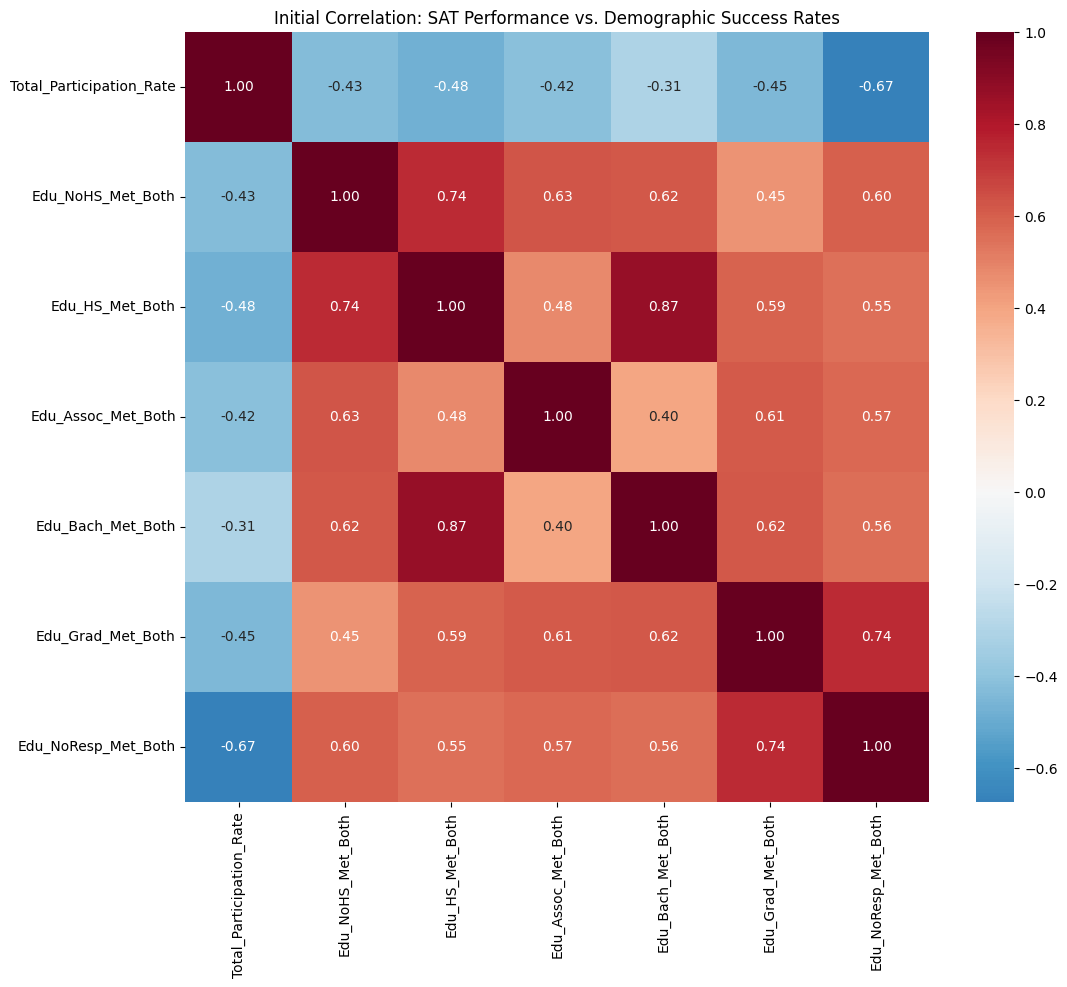

In [7]:
# 5. Generate the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Initial Correlation: SAT Performance vs. Demographic Success Rates')
plt.show()

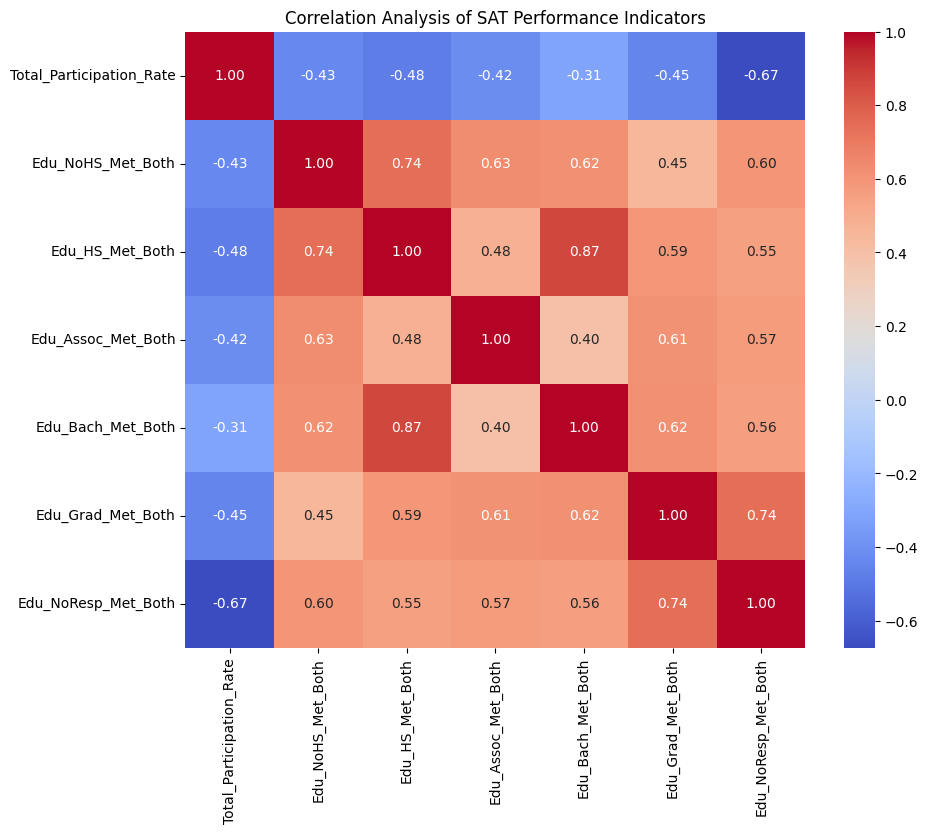

In [8]:
# 5a. Same Plot but different colors
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Analysis of SAT Performance Indicators")
plt.show()

In [10]:
# Now lets test for multi-collinearity
## Specifically pulling the success rates for both the highest income quintile and the highest educational attainment

# 1. Manually specify the columns to test your hypothesis
# Using 'Highest' and 'Graduate' to see if they tell the same story
collinearity_test_cols = [
    'Mean_Total_Score',          # Target
    'Total_Participation_Rate',  # Critical Control
    'Inc_Highest_Met_Both',      # Top Income Success
    'Edu_Grad_Met_Both',         # Top Education Success
    'Inc_Lowest_Met_Both',       # Bottom Income Success
    'Edu_NoHS_Met_Both'          # Bottom Education Success
]

In [11]:
# Ensure column names match exactly (adjusting for potential extraction naming)
actual_cols = [c for c in collinearity_test_cols if c in df_cb.columns]

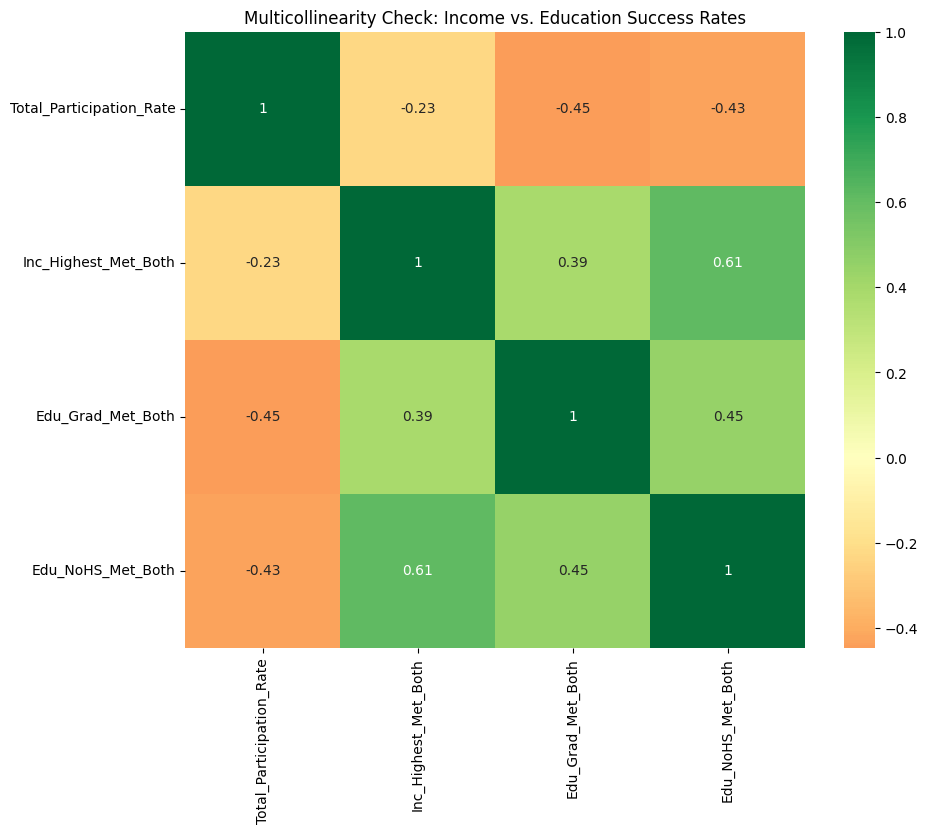

In [12]:
# 2. Running the Correlation
corr_matrix = df_cb[actual_cols].corr()

# 3. Plotting the Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Multicollinearity Check: Income vs. Education Success Rates')
plt.show()

In [13]:
# 4. Diagnostic Print
if 'Inc_Highest_Met_Both' in corr_matrix and 'Edu_Grad_Met_Both' in corr_matrix:
    r_val = corr_matrix.loc['Inc_Highest_Met_Both', 'Edu_Grad_Met_Both']
    print(f"Correlation between High Income and High Education Success: {r_val:.4f}")
    if r_val > 0.90:
        print("RESULT: High Multicollinearity detected. Ridge Regression is recommended.")
    else:
        print("RESULT: Features are distinct enough for standard regression evaluation.")

Correlation between High Income and High Education Success: 0.3863
RESULT: Features are distinct enough for standard regression evaluation.


#### <span style="color:orange;">That is a very significant finding for our project.</span>

*A correlation of 0.3863 is much lower than many educational researchers would expect. It suggests that, at the state level, a high "Graduate Degree" success rate (academic capital) does not automatically move in lockstep with the "Highest Income" success rate (financial capital).*

### What this means for our models:
**Linear Regression**: Since the correlation is below 0.90, we don't have to worry about the model "breaking" due to perfect multicollinearity. We can safely include both features to see which one has a higher coefficient (beta weight).
**Ridge Regression**: Even though collinearity is low, Ridge will still be useful for "fine-tuning" the weights of these two distinct predictors.

**The "*Structural*" Story**: This result supports our goal of identifying "*structural inequities*." It implies that income and education are acting as independent levers on SAT performance.

### **Peforming more "Rigorous Data Exploration," to perform a multi-dimensional visualization of the College Board dataset.**

Our goal here would be to identify *Outliers, Skewness, and Disparities*. For instance, identifying which states "*punch above their weight*" given their income levels is a sophisticated insight that evaluators may look for.

In [15]:
# Let's reload the dataset into a DataFrame for the next steps
df = pd.read_csv('data/sat_comprehensive_capstone_data.csv')

In [17]:
df.head()

,State,Total_SAT_Takers,Total_Participation_Rate,Race_Asian_N,Race_Asian_Pct,Race_Asian_Mean_Tot,Race_Asian_Mean_ERW,Race_Asian_Mean_Math,Race_Asian_Met_Both,Race_Asian_Met_ERW,...,Race_AmInd_Met_ERW,Race_AmInd_Met_Math,Race_NatHaw_N,Race_NatHaw_Pct,Race_NatHaw_Mean_Tot,Race_NatHaw_Mean_ERW,Race_NatHaw_Mean_Math,Race_NatHaw_Met_Both,Race_NatHaw_Met_ERW,Race_NatHaw_Met_Math
0,Alabama,1556,0.03,234.0,0.15,1297.0,632.0,665.0,0.86,0.92,...,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00
1,Alaska,2332,0.27,139.0,0.06,1083.0,545.0,539.0,0.50,0.78,...,0.44,0.20,14.0,0.01,1061.0,547.0,514.0,0.43,0.79,0.43
2,Arizona,8327,0.10,1346.0,0.16,1306.0,645.0,661.0,0.88,0.94,...,0.66,0.44,12.0,0.00,1076.0,545.0,531.0,0.58,0.83,0.58
3,Arkansas,783,0.02,117.0,0.15,1278.0,636.0,641.0,0.81,0.92,...,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00
4,California,123259,0.26,27106.0,0.22,1278.0,632.0,646.0,0.83,0.92,...,0.55,0.29,339.0,0.00,994.0,503.0,492.0,0.35,0.55,0.36


In [18]:
df.describe()

,Total_SAT_Takers,Total_Participation_Rate,Race_Asian_N,Race_Asian_Pct,Race_Asian_Mean_Tot,Race_Asian_Mean_ERW,Race_Asian_Mean_Math,Race_Asian_Met_Both,Race_Asian_Met_ERW,Race_Asian_Met_Math,...,Race_AmInd_Met_ERW,Race_AmInd_Met_Math,Race_NatHaw_N,Race_NatHaw_Pct,Race_NatHaw_Mean_Tot,Race_NatHaw_Mean_ERW,Race_NatHaw_Mean_Math,Race_NatHaw_Met_Both,Race_NatHaw_Met_ERW,Race_NatHaw_Met_Math
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,...,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,34219.396226,0.386415,2833.056604,0.098868,1157.132075,571.698113,585.358491,0.694906,0.811132,0.725283,...,0.297547,0.137358,47.490566,0.001509,481.943396,245.207547,236.754717,0.134340,0.268679,0.138491
std,57642.678205,0.370784,5400.923366,0.070347,294.706702,145.113693,149.782033,0.208664,0.214760,0.214938,...,0.279883,0.143180,92.079736,0.007178,480.907572,244.704245,236.283801,0.158084,0.291317,0.160305
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1219.000000,0.020000,139.000000,0.040000,1163.000000,577.000000,596.000000,0.630000,0.810000,0.690000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8327.000000,0.270000,410.000000,0.080000,1220.000000,603.000000,617.000000,0.730000,0.860000,0.770000,...,0.350000,0.120000,10.000000,0.000000,798.000000,415.000000,381.000000,0.090000,0.260000,0.090000
75%,43814.000000,0.730000,3041.000000,0.140000,1280.000000,632.000000,657.000000,0.830000,0.920000,0.880000,...,0.510000,0.230000,38.000000,0.000000,943.000000,483.000000,467.000000,0.240000,0.480000,0.250000
max,301020.000000,1.000000,27106.000000,0.310000,1346.000000,668.000000,689.000000,0.950000,1.000000,0.960000,...,0.830000,0.470000,390.000000,0.050000,1108.000000,565.000000,543.000000,0.580000,0.850000,0.580000


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Columns: 179 entries, State to Race_NatHaw_Met_Math
dtypes: float64(177), int64(1), object(1)
memory usage: 74.2+ KB


In [20]:
df.columns.tolist()

['State',
 'Total_SAT_Takers',
 'Total_Participation_Rate',
 'Race_Asian_N',
 'Race_Asian_Pct',
 'Race_Asian_Mean_Tot',
 'Race_Asian_Mean_ERW',
 'Race_Asian_Mean_Math',
 'Race_Asian_Met_Both',
 'Race_Asian_Met_ERW',
 'Race_Asian_Met_Math',
 'Race_Black_N',
 'Race_Black_Pct',
 'Race_Black_Mean_Tot',
 'Race_Black_Mean_ERW',
 'Race_Black_Mean_Math',
 'Race_Black_Met_Both',
 'Race_Black_Met_ERW',
 'Race_Black_Met_Math',
 'Race_Hispanic_N',
 'Race_Hispanic_Pct',
 'Race_Hispanic_Mean_Tot',
 'Race_Hispanic_Mean_ERW',
 'Race_Hispanic_Mean_Math',
 'Race_Hispanic_Met_Both',
 'Race_Hispanic_Met_ERW',
 'Race_Hispanic_Met_Math',
 'Race_White_N',
 'Race_White_Pct',
 'Race_White_Mean_Tot',
 'Race_White_Mean_ERW',
 'Race_White_Mean_Math',
 'Race_White_Met_Both',
 'Race_White_Met_ERW',
 'Race_White_Met_Math',
 'Race_Multi_N',
 'Race_Multi_Pct',
 'Race_Multi_Mean_Tot',
 'Race_Multi_Mean_ERW',
 'Race_Multi_Mean_Math',
 'Race_Multi_Met_Both',
 'Race_Multi_Met_ERW',
 'Race_Multi_Met_Math',
 'Race_NoResp_N'

In [21]:
# --- COLUMN DISCOVERY HELPER ---
def find_col(keywords, df):
    """Finds the first column that contains ALL keywords."""
    for col in df.columns:
        if all(k.lower() in col.lower() for k in keywords):
            return col
    return None

# Mapping targets and participation
target_total = find_col(['Mean', 'Total'], df)
target_erw = find_col(['Mean', 'ERW'], df)
target_math = find_col(['Mean', 'Math'], df)
part_rate = find_col(['Participation', 'Rate'], df)

print(f"Detected Target Column: {target_total}")

Detected Target Column: None


In [16]:
# 1. DISTRIBUTION ANALYSIS: How do scores look across the US?
plt.figure(figsize=(10, 5))
sns.histplot(df['Mean_Total_Score'], bins=15, kde=True, color='teal')
plt.title('Distribution of State Mean SAT Total Scores')
plt.xlabel('Mean Total Score')
plt.show()

KeyError: 'Mean_Total_Score'

<Figure size 1000x500 with 0 Axes>

In [ ]:
# 2. STATE RANKINGS: Top and Bottom Performers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_10 = df.nlargest(10, 'Mean_Total_Score')
sns.barplot(data=top_10, x='Mean_Total_Score', y='State', ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 States by Mean Total Score')

# Note: Remember the 'Participation Bias' here—high scores often have low participation!
bottom_10 = df.nsmallest(10, 'Mean_Total_Score')
sns.barplot(data=bottom_10, x='Mean_Total_Score', y='State', ax=axes[1], palette='magma')
axes[1].set_title('Bottom 10 States by Mean Total Score')
plt.tight_layout()
plt.show()

In [ ]:
# 3. INCOME QUINTILE CORRELATION: Every Income Slab vs. Total Score
# We gather all 'Met_Both' columns for Income
income_cols = [c for c in df.columns if 'Inc_' in c and 'Met_Both' in c]
# Sort them from Lowest to Highest for a logical plot
income_cols.sort() 

income_corr_df = df[['Mean_Total_Score'] + income_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(income_corr_df[['Mean_Total_Score']].sort_values(by='Mean_Total_Score', ascending=False), 
            annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation: Benchmark Success by Income Slab vs. State Mean Total')
plt.show()

In [ ]:
# 4. GENDER GAP ANALYSIS
gender_scores = {
    'Female': df['Gen_Female_Mean_Tot'].mean(),
    'Male': df['Gen_Male_Mean_Tot'].mean(),
    'No Response': df['Gen_NoResp_Mean_Tot'].mean()
}

plt.figure(figsize=(8, 6))
plt.bar(gender_scores.keys(), gender_scores.values(), color=['pink', 'skyblue', 'lightgrey'])
plt.ylim(df['Mean_Total_Score'].min() - 50, df['Mean_Total_Score'].max() + 50)
plt.title('Average State Mean Score by Gender Category')
plt.ylabel('Score')
plt.show()

In [ ]:
# 5. RACE/ETHNICITY BENCHMARK HEATMAP
race_cols = [c for c in df.columns if 'Race_' in c and 'Met_Both' in c]
race_bench_df = df.set_index('State')[race_cols]

plt.figure(figsize=(14, 10))
sns.heatmap(race_bench_df.sample(15), annot=True, cmap='Purples', fmt=".0%")
plt.title('Sample of States: % Meeting Both Benchmarks by Race/Ethnicity')
plt.show()